# 06 — Hyperparameter analysis (Option A: family-first)

This notebook explains *predictive multiplicity* within a Rashomon set by decomposing prediction variance:

- **Step 1 (Option A):** quantify how much multiplicity is explained by **model family** (e.g., GBM vs MLP vs RF).
- **Step 2:** within each family, quantify which **hyperparameters** explain multiplicity (dropping missing HP values so they don't act as a family proxy).
- **Step 3:** repeat the within-family HP analysis **inside HH hotspots** (from LISA) to find *hotspot-specific drivers*.

Outputs (saved automatically):
- `tables/family_importance_{dataset}_seed{seed}.csv`
- `tables/hp_importance_within_family_{dataset}_seed{seed}.csv`
- `tables/hp_importance_within_family_HH_{dataset}_seed{seed}.csv`
- `tables/family_importance_subsets_{dataset}_seed{seed}.csv`
- `figures/family_between_ratio_hist_{dataset}_seed{seed}.pdf`
- `figures/within_family_hp_importance_{dataset}_seed{seed}_{family}.pdf`
- `figures/hh_delta_hp_importance_{dataset}_seed{seed}_{family}.pdf`
- `figures/family_importance_by_subset_{dataset}_seed{seed}.pdf`


In [1]:
# 1) Imports and path setup
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from analysis.run_analysis import (
    load_meta,
    load_P_test,
    select_rashomon_global,
    select_rashomon_per_family_k_each,
    run_spatial,
)
from analysis.preprocessing import get_transformed_test_features

import analysis.hyperparams as hp
importlib.reload(hp)

from analysis.hyperparams import (
    ensure_hp_columns,
    variance_decomposition_by_groups,
    compute_family_importance,
    compute_hp_importance,
    compute_within_family_hp_importance,
    compute_within_family_hp_importance_on_subset,
    hyperparameter_profiling,
)

RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "figures"
TABLE_DIR = ROOT / "tables"
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


## Configuration

- `DATASET` should match a directory under `results/`.
- `SEED` should match a run directory like `results/{dataset}/seed={SEED}/`.
- `K` is the Rashomon size per family (top-K by validation metric within each family).
- `K_NN` is the kNN size used for Moran/LISA to detect HH hotspots.


In [2]:
# 2) Configuration (edit these)
DATASET = "compas"
SEED = 0

K = 25        # Rashomon top-K per family
K_NN = 30     # kNN for spatial weights (Moran/LISA)

# Optional: used for profiling local Rashomon sets per HP value
PROFILE_EPS = 0.01


In [3]:
# 3) Load run artifacts and select Rashomon per family (top-K within each family)
run_dir = RESULTS_DIR / DATASET / f"seed={SEED}"
if not run_dir.exists():
    raise FileNotFoundError(f"Run directory not found: {run_dir}")

meta_all = load_meta(run_dir)
P_test_all = load_P_test(run_dir)

K_actual = min(K, len(meta_all))
idx_all = select_rashomon_per_family_k_each(run_dir, K_each=K_actual)
P_sel = P_test_all[idx_all]
meta_sel = meta_all.iloc[idx_all].reset_index(drop=True)
meta_sel = ensure_hp_columns(meta_sel)
P = P_sel
meta = meta_sel

print(f"Run: {run_dir}")
print(f"Candidates: {len(meta_all)}, Rashomon K per family: {K_actual}, Test points: {P.shape[1]}")
print(meta_sel["model_name"].value_counts())
display(meta_sel["model_name"].value_counts())


Run: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\compas\seed=0
Candidates: 250, Rashomon K per family: 25, Test points: 1443
model_name
GBM       25
LogReg    25
MLP       25
RF        25
kNN       25
Name: count, dtype: int64


model_name
GBM       25
LogReg    25
MLP       25
RF        25
kNN       25
Name: count, dtype: int64

## Per-family HP importance and HH-only drivers

Loop over families; for each family compute within-family HP importance, save table and figure. Optionally compute HH mask from that family's pointwise variance and HP importance on HH subset (with delta plot vs all).

In [4]:
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import spatial_analysis

def family_hh_mask(P_family, X_test, k_nn=30, permutations=999, alpha=0.05, seed=42):
    """HH mask from LISA on this family's pointwise variance."""
    v = np.var(P_family, axis=0, ddof=0)
    sp = spatial_analysis(v, X_test, k=k_nn, permutations=permutations, fdr_alpha=alpha, seed=seed)
    HH = sp["HH_mask"]
    return HH, v, sp["W"], sp

X_test = get_transformed_test_features(run_dir, DATASET)
meta_sel = ensure_hp_columns(meta_sel)
families = sorted(meta_sel["model_name"].unique())

for fam in families:
    mask = (meta_sel["model_name"] == fam).values
    P_f = P_sel[mask]
    meta_f = meta_sel.loc[mask].reset_index(drop=True)

    if len(meta_f) < 3:
        continue

    df_imp = compute_hp_importance(P_f, meta_f, model_family=None, dropna=True)
    out_csv = TABLE_DIR / f"hp_importance_{DATASET}_seed{SEED}_{fam}.csv"
    df_imp.to_csv(out_csv, index=False)

    top = df_imp.head(8).iloc[::-1]
    plt.figure(figsize=(7, 4))
    plt.barh(top["hyperparameter"], top["ratio_of_sums"])
    plt.xlabel("ratio_of_sums (between-hp / total)")
    plt.title(f"{DATASET} | seed {SEED} | {fam} — within-family HP importance")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"hp_importance_{DATASET}_seed{SEED}_{fam}.pdf")
    plt.close()
    display(df_imp.head(12))

    # HH-only: family's pointwise variance -> LISA HH -> HP importance on HH subset
    HH_mask, v_f, W_f, lisa_f = family_hh_mask(P_f, X_test, k_nn=K_NN, seed=SEED)
    df_hh = compute_within_family_hp_importance_on_subset(
        meta_f, P_f, obs_mask=HH_mask, min_models_per_family=3, dropna=True
    )
    out_csv_hh = TABLE_DIR / f"hp_importance_HH_{DATASET}_seed{SEED}_{fam}.csv"
    df_hh.to_csv(out_csv_hh, index=False)

    df_all = compute_hp_importance(P_f, meta_f, dropna=True)
    m_all = df_all.set_index("hyperparameter")["ratio_of_sums"]
    m_hh = df_hh.set_index("hp")["ratio_of_sums"] if not df_hh.empty else pd.Series(dtype=float)
    common = sorted(set(m_all.index) & set(m_hh.index))
    if common:
        delta = (m_hh.reindex(common).fillna(0) - m_all[common]).sort_values()
        plt.figure(figsize=(7, 4))
        plt.barh(delta.index, delta.values)
        plt.axvline(0, linestyle="--", linewidth=1)
        plt.xlabel("Δ ratio_of_sums (HH − all)")
        plt.title(f"{DATASET} | seed {SEED} | {fam} — HP importance shift in HH")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"hp_delta_HH_{DATASET}_seed{SEED}_{fam}.pdf")
        plt.close()

,hyperparameter,mean_var_between_ratio,ratio_of_sums,median_ratio,p90_ratio,mean_var_within_ratio,n_values,n_groups,n_models_total,n_models_used
0,learning_rate,0.332212,0.337331,0.329488,0.577683,0.667788,4,4,25,25
1,max_depth,0.272210,0.258144,0.224052,0.575924,0.727790,4,4,25,25
2,subsample,0.105786,0.088820,0.079214,0.241418,0.894214,3,3,25,25
3,n_estimators,0.071474,0.065849,0.061831,0.140820,0.928526,3,3,25,25


,hyperparameter,mean_var_between_ratio,ratio_of_sums,median_ratio,p90_ratio,mean_var_within_ratio,n_values,n_groups,n_models_total,n_models_used
0,C,0.768284,0.864779,0.854287,0.994075,0.231716,10,10,25,25
1,l1_ratio,0.093918,0.049767,0.072149,0.188798,0.906082,5,5,25,25


,hyperparameter,mean_var_between_ratio,ratio_of_sums,median_ratio,p90_ratio,mean_var_within_ratio,n_values,n_groups,n_models_total,n_models_used
0,alpha,0.236809,0.250357,0.219403,0.415270,0.763191,4,4,25,25
1,learning_rate_init,0.141207,0.188544,0.115525,0.313149,0.858793,3,3,25,25
2,hidden_layer_sizes,0.136856,0.140204,0.119589,0.267956,0.863144,5,5,25,25
3,activation,0.054976,0.057733,0.023437,0.129546,0.945024,2,2,25,25


,hyperparameter,mean_var_between_ratio,ratio_of_sums,median_ratio,p90_ratio,mean_var_within_ratio,n_values,n_groups,n_models_total,n_models_used
0,max_depth,0.589222,0.667414,0.656749,0.945346,0.410778,4,4,25,24
1,min_samples_split,0.107037,0.121744,0.107552,0.195657,0.892963,3,3,25,25
2,min_samples_leaf,0.072405,0.060663,0.055861,0.148904,0.927595,3,3,25,25
3,max_features,0.031331,0.030012,0.027040,0.060264,0.968669,2,2,25,20
4,n_estimators,0.034894,0.025610,0.021478,0.087136,0.965106,3,3,25,25


,hyperparameter,mean_var_between_ratio,ratio_of_sums,median_ratio,p90_ratio,mean_var_within_ratio,n_values,n_groups,n_models_total,n_models_used
0,n_neighbors,0.836265,0.835594,0.877899,0.983013,0.163735,13,13,25,25
1,weights,0.139080,0.175321,0.042479,0.498001,0.860920,2,2,25,25
2,p,0.015990,0.015031,0.005373,0.037628,0.984010,2,2,25,25


## Step 1 — Family-first decomposition (Option A)

We first treat **model family** (`model_name`) as the factor and decompose prediction variance into:
- between-family
- within-family

This answers: *How much of the multiplicity is just “which algorithm family you chose”?*


In [5]:
# 4) Family importance (summary stats)
family_summary = compute_family_importance(meta, P, family_col="model_name")
display(family_summary)

family_summary_path = TABLE_DIR / f"family_importance_{DATASET}_seed{SEED}.csv"
family_summary.to_csv(family_summary_path, index=False)
print("Saved:", family_summary_path)


,factor,n_models_total,n_models_used,n_groups,mean_ratio,median_ratio,p90_ratio,ratio_of_sums
0,model_name,125,125,5,0.335971,0.323766,0.592339,0.388554


Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables\family_importance_compas_seed0.csv


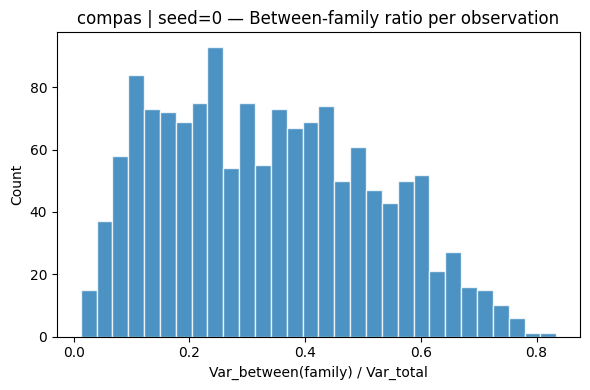

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\family_between_ratio_hist_compas_seed0.pdf


In [6]:
# 5) Family importance (distribution over observations)
out_fam = variance_decomposition_by_groups(P, meta["model_name"].astype(str).values, min_group_size=1)
ratio_fam = out_fam["ratio"]

plt.figure(figsize=(6, 4))
plt.hist(ratio_fam, bins=30, edgecolor="white", alpha=0.8)
plt.xlabel("Var_between(family) / Var_total")
plt.ylabel("Count")
plt.title(f"{DATASET} | seed={SEED} — Between-family ratio per observation")
plt.tight_layout()

fig_path = FIG_DIR / f"family_between_ratio_hist_{DATASET}_seed{SEED}.pdf"
plt.savefig(fig_path)
plt.show()
plt.close()
print("Saved:", fig_path)


## Step 2 — Within-family hyperparameter importance

Now we compute the same decomposition **within each model family**.
Crucially, for each HP we **drop missing values** so “nan” does not act as a proxy for family.

We report multiple summaries:
- `ratio_of_sums` (stable):  sum(var_between) / sum(var_total)
- `mean_ratio` (mean of per-observation ratios)
- `median_ratio`, `p90_ratio` (to detect localized effects)


In [7]:
# 6) Within-family HP importance (all observations)
hp_imp = compute_within_family_hp_importance(
    meta,
    P,
    hp_cols=None,               # None => use all hp_* columns
    family_col="model_name",
    min_models_per_family=3,
    min_groups=2,
    min_group_size=1,
    dropna=True,
)

display(hp_imp.head(30))

hp_imp_path = TABLE_DIR / f"hp_importance_within_family_{DATASET}_seed{SEED}.csv"
hp_imp.to_csv(hp_imp_path, index=False)
print("Saved:", hp_imp_path)


,family,hp,hp_col,n_models_total_family,n_models_used,n_groups,mean_ratio,median_ratio,p90_ratio,ratio_of_sums
0,GBM,learning_rate,hp_learning_rate,25,25,4,0.332212,0.329488,0.577683,0.337331
1,GBM,max_depth,hp_max_depth,25,25,4,0.272210,0.224052,0.575924,0.258144
2,GBM,subsample,hp_subsample,25,25,3,0.105786,0.079214,0.241418,0.088820
3,GBM,n_estimators,hp_n_estimators,25,25,3,0.071474,0.061831,0.140820,0.065849
4,LogReg,C,hp_C,25,25,10,0.768284,0.854287,0.994075,0.864779
5,LogReg,l1_ratio,hp_l1_ratio,25,25,5,0.093918,0.072149,0.188798,0.049767
6,MLP,alpha,hp_alpha,25,25,4,0.236809,0.219403,0.415270,0.250357
7,MLP,learning_rate_init,hp_learning_rate_init,25,25,3,0.141207,0.115525,0.313149,0.188544
8,MLP,hidden_layer_sizes,hp_hidden_layer_sizes,25,25,5,0.136856,0.119589,0.267956,0.140204
9,MLP,activation,hp_activation,25,25,2,0.054976,0.023437,0.129546,0.057733


Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables\hp_importance_within_family_compas_seed0.csv


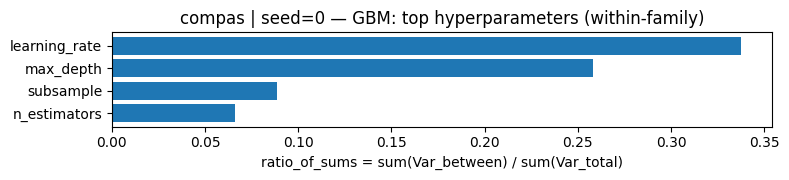

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\within_family_hp_importance_compas_seed0_GBM.pdf


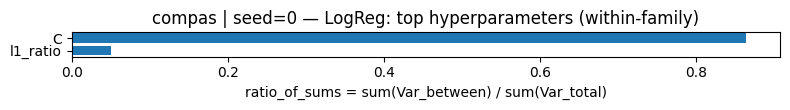

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\within_family_hp_importance_compas_seed0_LogReg.pdf


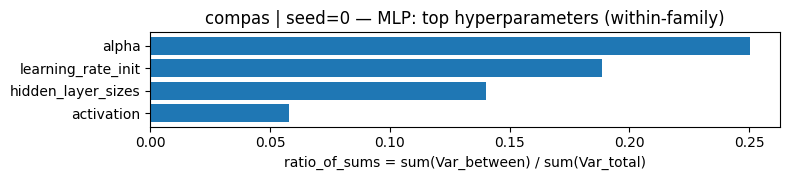

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\within_family_hp_importance_compas_seed0_MLP.pdf


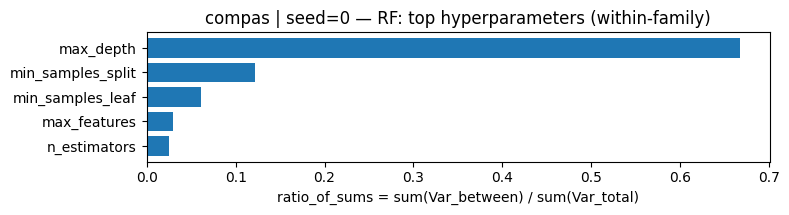

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\within_family_hp_importance_compas_seed0_RF.pdf


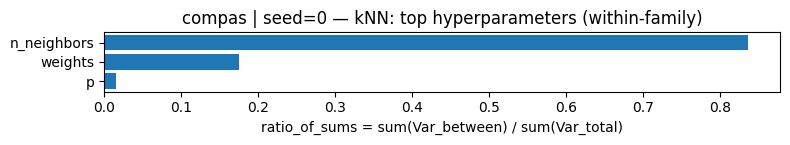

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\within_family_hp_importance_compas_seed0_kNN.pdf


In [8]:
# 7) Plot top hyperparameters per family
TOP_K = 7

for fam, df_f in hp_imp.groupby("family"):
    df_top = df_f.sort_values("ratio_of_sums", ascending=False).head(TOP_K).copy()
    if df_top.empty:
        continue

    plt.figure(figsize=(8, 0.5 + 0.35 * len(df_top)))
    plt.barh(df_top["hp"][::-1], df_top["ratio_of_sums"][::-1])
    plt.xlabel("ratio_of_sums = sum(Var_between) / sum(Var_total)")
    plt.title(f"{DATASET} | seed={SEED} — {fam}: top hyperparameters (within-family)")
    plt.tight_layout()

    fig_path = FIG_DIR / f"within_family_hp_importance_{DATASET}_seed{SEED}_{fam}.pdf"
    plt.savefig(fig_path)
    plt.show()
    plt.close()
    print("Saved:", fig_path)


## Step 3 — Hotspot-specific hyperparameter drivers (HH points)

We compute HH hotspots from LISA (on pointwise predictive variance), then repeat the within-family
HP importance analysis **restricted to HH points only**.

This answers: *Do different hyperparameters matter more inside hotspots than overall?*


In [9]:
# 8) Compute HH hotspots (LISA) for this run
X_test = get_transformed_test_features(run_dir, DATASET)

# Ensure dense numeric array (kNN + PySAL expects dense)
if hasattr(X_test, "toarray"):
    X_test = X_test.toarray()
else:
    X_test = np.asarray(X_test)
X_test = np.asarray(X_test, dtype=float)

spatial = run_spatial(run_dir, X_test, K=K_actual, k=K_NN, seed=SEED, selection="per_family")
HH_mask = np.asarray(spatial["HH_mask"], dtype=bool)
LL_mask = np.asarray(spatial["LL_mask"], dtype=bool)

print(f"Moran's I: {spatial['moran_i']:.4f}")
print(f"HH count: {HH_mask.sum()}, LL count: {LL_mask.sum()}, n_test={len(HH_mask)}")


Moran's I: 0.2108
HH count: 125, LL count: 509, n_test=1443


In [10]:
# 9) Within-family HP importance (HH-only)
hp_imp_hh = compute_within_family_hp_importance_on_subset(
    meta,
    P,
    obs_mask=HH_mask,
    hp_cols=None,
    family_col="model_name",
    min_models_per_family=3,
    min_groups=2,
    min_group_size=1,
    dropna=True,
)

display(hp_imp_hh.head(30))

hp_imp_hh_path = TABLE_DIR / f"hp_importance_within_family_HH_{DATASET}_seed{SEED}.csv"
hp_imp_hh.to_csv(hp_imp_hh_path, index=False)
print("Saved:", hp_imp_hh_path)


,family,hp,hp_col,n_models_total_family,n_models_used,n_groups,mean_ratio,median_ratio,p90_ratio,ratio_of_sums
0,GBM,learning_rate,hp_learning_rate,25,25,4,0.319029,0.325200,0.598538,0.326202
1,GBM,max_depth,hp_max_depth,25,25,4,0.213490,0.190653,0.394637,0.235007
2,GBM,subsample,hp_subsample,25,25,3,0.114970,0.085243,0.238061,0.084258
3,GBM,n_estimators,hp_n_estimators,25,25,3,0.062661,0.060792,0.110659,0.060192
4,LogReg,C,hp_C,25,25,10,0.831845,0.874540,0.997612,0.738158
5,LogReg,l1_ratio,hp_l1_ratio,25,25,5,0.081608,0.065989,0.135209,0.080512
6,MLP,learning_rate_init,hp_learning_rate_init,25,25,3,0.247346,0.231852,0.488280,0.314869
7,MLP,alpha,hp_alpha,25,25,4,0.245718,0.225178,0.449556,0.230391
8,MLP,hidden_layer_sizes,hp_hidden_layer_sizes,25,25,5,0.149987,0.135816,0.293900,0.154773
9,MLP,activation,hp_activation,25,25,2,0.067028,0.026998,0.134088,0.066639


Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables\hp_importance_within_family_HH_compas_seed0.csv


In [11]:
# 10) Compare HH vs ALL (delta importance)
if not hp_imp_hh.empty:
    merged = hp_imp.merge(
        hp_imp_hh[["family", "hp", "ratio_of_sums", "mean_ratio", "median_ratio", "p90_ratio"]],
        on=["family", "hp"],
        how="left",
        suffixes=("_all", "_HH"),
    )
    merged["delta_ratio_of_sums"] = merged["ratio_of_sums_HH"] - merged["ratio_of_sums_all"]
    display(merged.sort_values("delta_ratio_of_sums", ascending=False).head(25))
else:
    merged = pd.DataFrame()
    print("No HH-only HP importance rows (possible if HH set is empty).")


,family,hp,hp_col,n_models_total_family,n_models_used,n_groups,mean_ratio_all,median_ratio_all,p90_ratio_all,ratio_of_sums_all,ratio_of_sums_HH,mean_ratio_HH,median_ratio_HH,p90_ratio_HH,delta_ratio_of_sums
7,MLP,learning_rate_init,hp_learning_rate_init,25,25,3,0.141207,0.115525,0.313149,0.188544,0.314869,0.247346,0.231852,0.488280,0.126325
5,LogReg,l1_ratio,hp_l1_ratio,25,25,5,0.093918,0.072149,0.188798,0.049767,0.080512,0.081608,0.065989,0.135209,0.030745
15,kNN,n_neighbors,hp_n_neighbors,25,25,13,0.836265,0.877899,0.983013,0.835594,0.858538,0.838736,0.888381,0.989002,0.022945
12,RF,min_samples_leaf,hp_min_samples_leaf,25,25,3,0.072405,0.055861,0.148904,0.060663,0.075682,0.082087,0.071093,0.161794,0.015019
8,MLP,hidden_layer_sizes,hp_hidden_layer_sizes,25,25,5,0.136856,0.119589,0.267956,0.140204,0.154773,0.149987,0.135816,0.293900,0.014569
9,MLP,activation,hp_activation,25,25,2,0.054976,0.023437,0.129546,0.057733,0.066639,0.067028,0.026998,0.134088,0.008905
17,kNN,p,hp_p,25,25,2,0.015990,0.005373,0.037628,0.015031,0.022027,0.024309,0.004798,0.054894,0.006997
14,RF,n_estimators,hp_n_estimators,25,25,3,0.034894,0.021478,0.087136,0.025610,0.022884,0.028851,0.017204,0.063040,-0.002726
13,RF,max_features,hp_max_features,25,20,2,0.031331,0.027040,0.060264,0.030012,0.026727,0.031037,0.025798,0.055296,-0.003285
2,GBM,subsample,hp_subsample,25,25,3,0.105786,0.079214,0.241418,0.088820,0.084258,0.114970,0.085243,0.238061,-0.004562


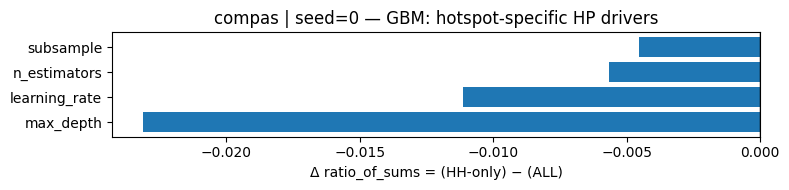

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hh_delta_hp_importance_compas_seed0_GBM.pdf


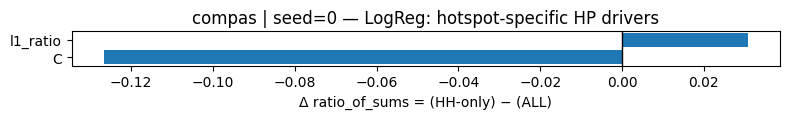

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hh_delta_hp_importance_compas_seed0_LogReg.pdf


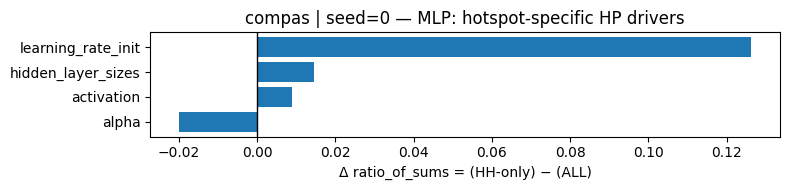

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hh_delta_hp_importance_compas_seed0_MLP.pdf


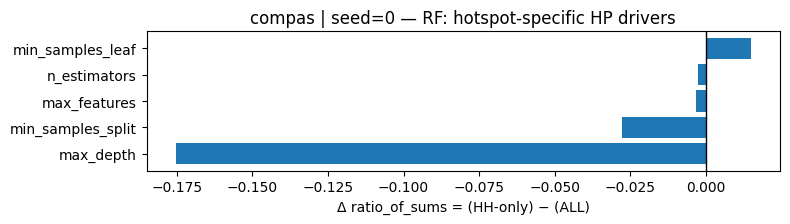

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hh_delta_hp_importance_compas_seed0_RF.pdf


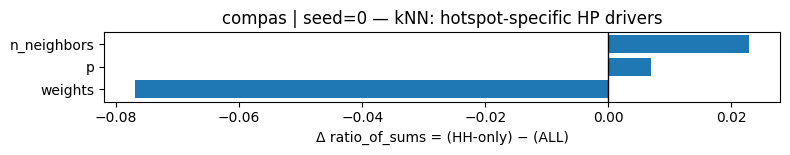

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\hh_delta_hp_importance_compas_seed0_kNN.pdf


In [12]:
# 11) Plot hotspot-specific drivers per family (Δ ratio_of_sums)
if not merged.empty:
    for fam, df_f in merged.groupby("family"):
        df_f = df_f.dropna(subset=["ratio_of_sums_HH"]).copy()
        if df_f.empty:
            continue

        df_top = df_f.sort_values("delta_ratio_of_sums", ascending=False).head(10)

        plt.figure(figsize=(8, 0.6 + 0.35 * len(df_top)))
        plt.barh(df_top["hp"][::-1], df_top["delta_ratio_of_sums"][::-1])
        plt.axvline(0.0, color="black", linewidth=1)
        plt.xlabel("Δ ratio_of_sums = (HH-only) − (ALL)")
        plt.title(f"{DATASET} | seed={SEED} — {fam}: hotspot-specific HP drivers")
        plt.tight_layout()

        fig_path = FIG_DIR / f"hh_delta_hp_importance_{DATASET}_seed{SEED}_{fam}.pdf"
        plt.savefig(fig_path)
        plt.show()
        plt.close()
        print("Saved:", fig_path)


## Step 4 — Family effect inside HH vs outside HH

This is a compact way to see whether hotspots are mainly driven by **family choice** or by
**within-family differences**.


,subset,mean_ratio,ratio_of_sums,median_ratio,p90_ratio,n_models_used,n_groups
0,ALL,0.335971,0.388554,0.323766,0.592339,125,5
1,HH,0.460155,0.496780,0.510147,0.676289,125,5
2,nonHH,0.324193,0.371305,0.309462,0.573121,125,5


Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables\family_importance_subsets_compas_seed0.csv


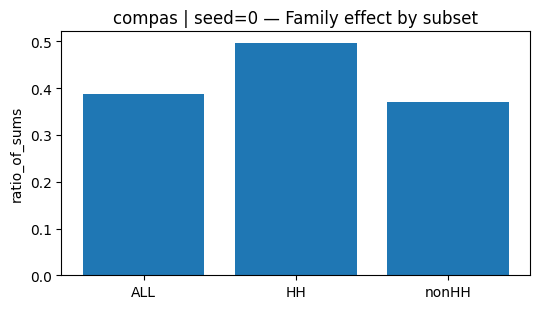

Saved: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\family_importance_by_subset_compas_seed0.pdf


In [13]:
# 12) Family importance by subset: ALL vs HH vs non-HH
fam_all = compute_family_importance(meta, P, family_col="model_name", obs_mask=None)
fam_hh = compute_family_importance(meta, P, family_col="model_name", obs_mask=HH_mask)
fam_non = compute_family_importance(meta, P, family_col="model_name", obs_mask=~HH_mask)

fam_compare = pd.concat(
    [
        fam_all.assign(subset="ALL"),
        fam_hh.assign(subset="HH"),
        fam_non.assign(subset="nonHH"),
    ],
    ignore_index=True,
)

cols = ["subset", "mean_ratio", "ratio_of_sums", "median_ratio", "p90_ratio", "n_models_used", "n_groups"]
display(fam_compare[cols])

fam_compare_path = TABLE_DIR / f"family_importance_subsets_{DATASET}_seed{SEED}.csv"
fam_compare.to_csv(fam_compare_path, index=False)
print("Saved:", fam_compare_path)

plt.figure(figsize=(5.5, 3.2))
plt.bar(fam_compare["subset"], fam_compare["ratio_of_sums"])
plt.ylabel("ratio_of_sums")
plt.title(f"{DATASET} | seed={SEED} — Family effect by subset")
plt.tight_layout()

fig_path = FIG_DIR / f"family_importance_by_subset_{DATASET}_seed{SEED}.pdf"
plt.savefig(fig_path)
plt.show()
plt.close()
print("Saved:", fig_path)


## Optional — Hyperparameter profiling (local Rashomon sets per HP value)

**Important:** Profiling is meaningful on the full candidate pool (`meta_all`), not only the
global Rashomon subset (otherwise “local fraction” may be trivially 1.0).

This section is useful to answer: “Which HP values are consistently good within a family?”


In [14]:
# 13) Profiling example (edit HP and family)
meta_all_exp = ensure_hp_columns(meta_all)

HP_TO_PROFILE = "max_depth"     # e.g., "max_depth", "learning_rate", "alpha"
FAMILY_TO_PROFILE = "GBM"       # e.g., "GBM", "MLP"

try:
    prof = hyperparameter_profiling(
        meta_all_exp,
        hp_name=HP_TO_PROFILE,
        epsilon=PROFILE_EPS,
        model_family=FAMILY_TO_PROFILE,
        dropna=True,
    )
    display(prof.head(20))
except Exception as e:
    print("Profiling failed:", e)


,hp_value,best_loss,local_rashomon_size,total_models,local_rashomon_fraction
0,3.0,0.206094,15,15,1.000000
1,4.0,0.206263,11,14,0.785714
2,2.0,0.206368,8,10,0.800000
3,5.0,0.207636,9,11,0.818182


## Global vs Per-family Moran/LISA comparison

Compare spatial metrics (Moran's I, HH count) between global and per-family Rashomon selection modes on the same run. This reveals whether hotspots are driven by inter-family diversity or persist within individual families.

,Selection,Moran's I,HH count,Mean variance
0,Global (K=25),0.140503,48,0.000841
1,Per-family (K=25/fam),0.210754,125,0.005422



Per individual family:


,Family,Moran's I,HH count,Mean variance,n_models
0,GBM,0.185069,66,0.001033,25
1,LogReg,0.068201,4,0.000006,25
2,MLP,0.518295,212,0.001066,25
3,RF,0.160490,68,0.003053,25
4,kNN,0.072913,69,0.011418,25


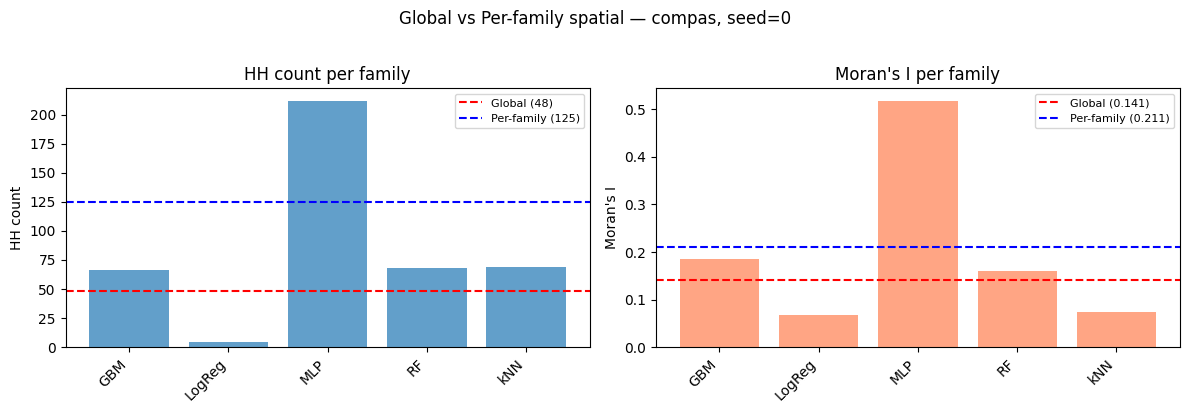

In [15]:
from analysis.run_analysis import (
    run_spatial_per_family, pointwise_variance, spatial_analysis,
    select_rashomon_global as _select_global,
    select_rashomon_per_family_k_each as _select_perfam,
    load_P_test as _load_P,
)

# Global Rashomon spatial
idx_global = _select_global(run_dir, K=K_actual)
P_global = _load_P(run_dir)[idx_global]
v_global = pointwise_variance(P_global)
sp_global = spatial_analysis(v_global, X_test, k=K_NN, seed=SEED)

# Per-family Rashomon spatial (already computed above, reuse)
sp_perfam = spatial  # from cell that computed per-family HH

# Per-family by individual family
fam_spatial = run_spatial_per_family(run_dir, X_test, K=K, k=K_NN, seed=SEED)

comparison = {
    "Selection": ["Global (K=25)", "Per-family (K=25/fam)"],
    "Moran's I": [sp_global["moran_i"], sp_perfam["moran_i"]],
    "HH count": [int(sp_global["HH_mask"].sum()), int(sp_perfam["HH_mask"].sum())],
    "Mean variance": [float(v_global.mean()), float(pointwise_variance(P_sel).mean())],
}
comp_df = pd.DataFrame(comparison)
display(comp_df)

# Per individual family
fam_rows = []
for family, res in fam_spatial.items():
    fam_rows.append({
        "Family": family,
        "Moran's I": res["moran_i"],
        "HH count": res["n_hh"],
        "Mean variance": res["mean_variance"],
        "n_models": res["n_models"],
    })
fam_comp_df = pd.DataFrame(fam_rows)
print("\nPer individual family:")
display(fam_comp_df)

# Save
comp_df.to_csv(TABLE_DIR / f"global_vs_perfamily_{DATASET}_seed{SEED}.csv", index=False)
fam_comp_df.to_csv(TABLE_DIR / f"perfamily_spatial_{DATASET}_seed{SEED}.csv", index=False)

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
families = fam_comp_df["Family"].values
x = range(len(families))

ax1.bar(x, fam_comp_df["HH count"], alpha=0.7)
ax1.axhline(int(sp_global["HH_mask"].sum()), color="red", ls="--", label=f"Global ({int(sp_global['HH_mask'].sum())})")
ax1.axhline(int(sp_perfam["HH_mask"].sum()), color="blue", ls="--", label=f"Per-family ({int(sp_perfam['HH_mask'].sum())})")
ax1.set_xticks(list(x)); ax1.set_xticklabels(families, rotation=45, ha="right")
ax1.set_ylabel("HH count"); ax1.set_title("HH count per family"); ax1.legend(fontsize=8)

ax2.bar(x, fam_comp_df["Moran's I"], alpha=0.7, color="coral")
ax2.axhline(sp_global["moran_i"], color="red", ls="--", label=f"Global ({sp_global['moran_i']:.3f})")
ax2.axhline(sp_perfam["moran_i"], color="blue", ls="--", label=f"Per-family ({sp_perfam['moran_i']:.3f})")
ax2.set_xticks(list(x)); ax2.set_xticklabels(families, rotation=45, ha="right")
ax2.set_ylabel("Moran's I"); ax2.set_title("Moran's I per family"); ax2.legend(fontsize=8)

fig.suptitle(f"Global vs Per-family spatial — {DATASET}, seed={SEED}", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / f"global_vs_perfamily_spatial_{DATASET}_seed{SEED}.pdf", bbox_inches="tight")
plt.show()

## Per-family predictive variance by HP value

Inspired by the predictive multiplicity literature: for each model family, plot the distribution of mean predictive variance grouped by hyperparameter value. This identifies which HP values are associated with the highest variance (most multiplicity).

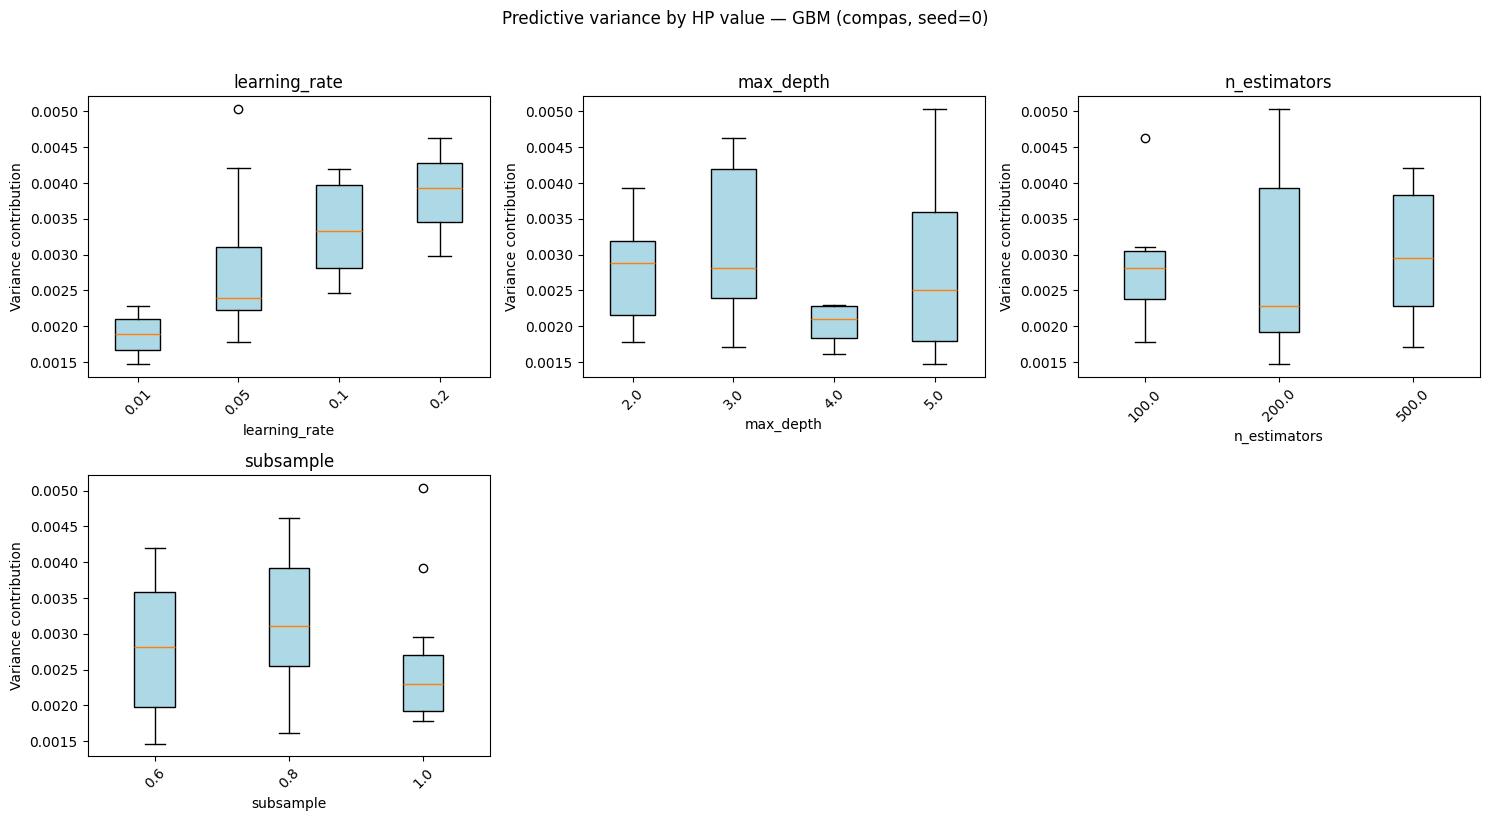

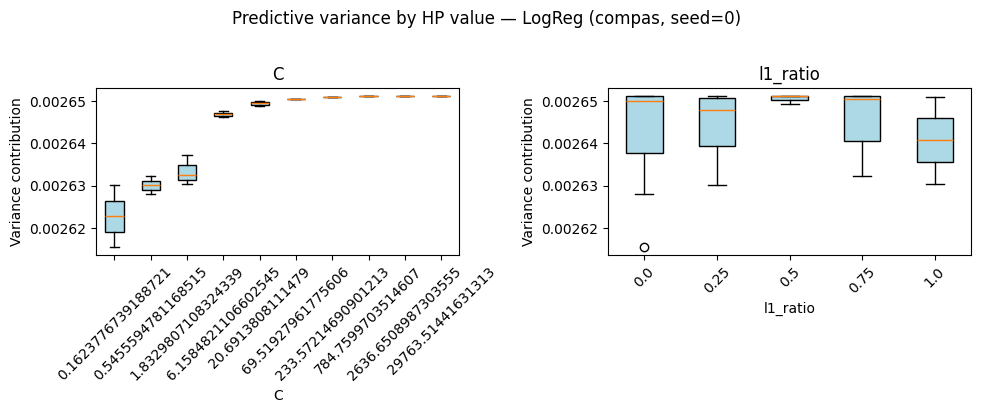

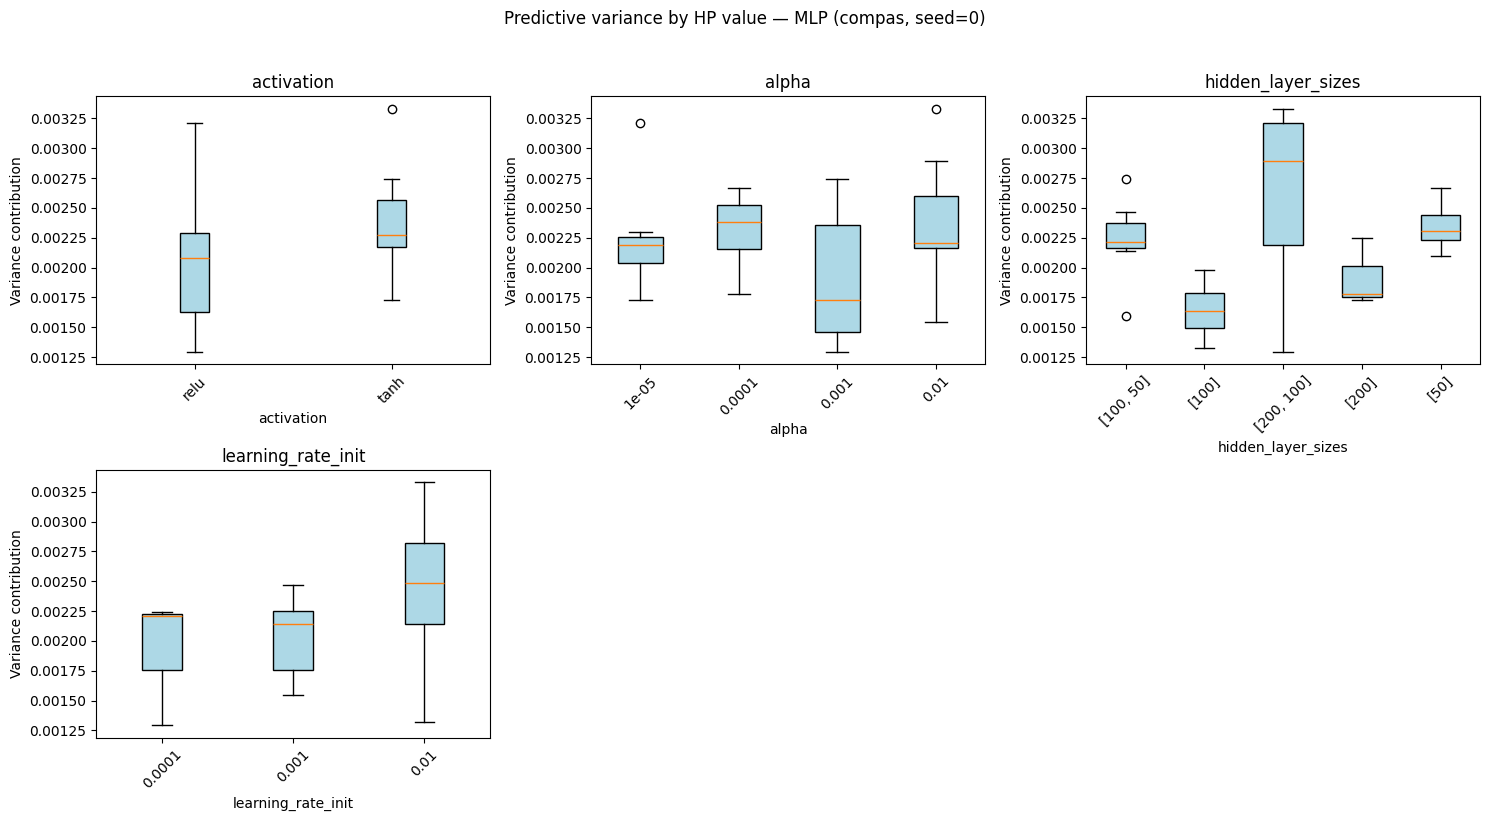

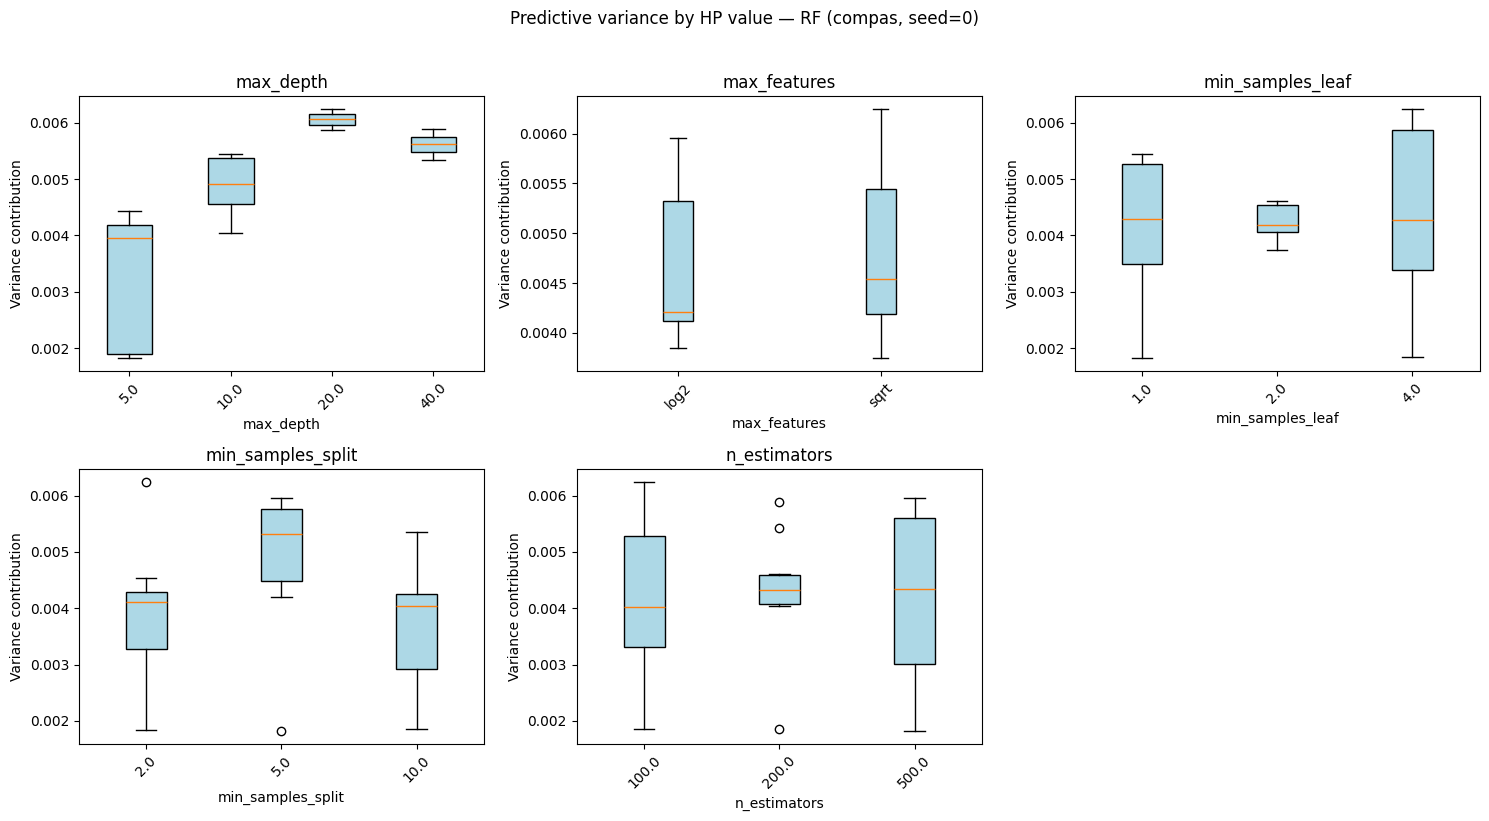

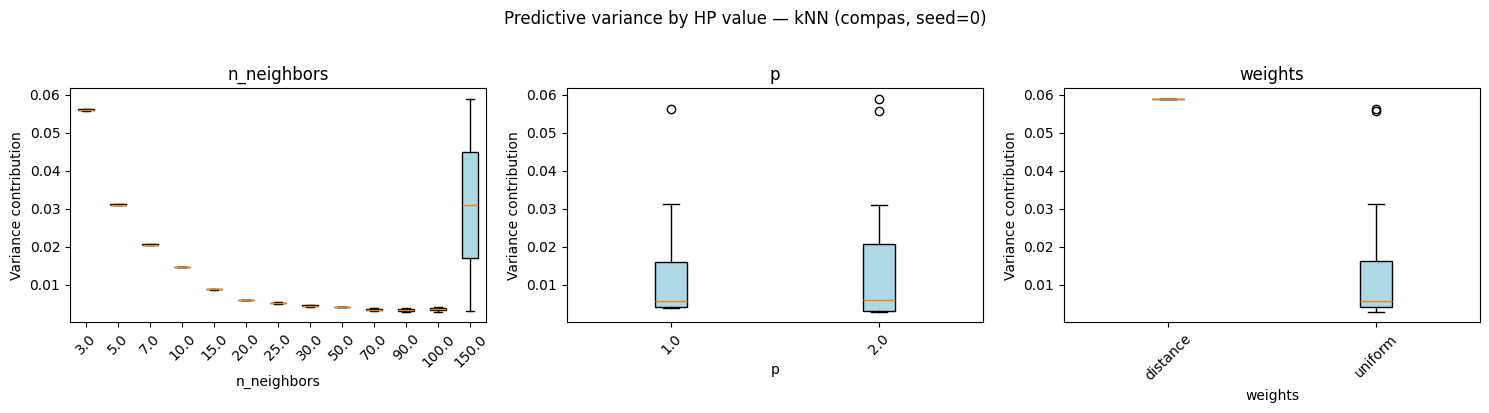

In [16]:
from analysis.hyperparams import ensure_hp_columns

# Compute per-model mean variance (average over test points)
model_mean_var = np.mean(np.var(P_sel, axis=0, ddof=0, keepdims=True).repeat(P_sel.shape[0], axis=0), axis=1)
# Actually: for each model m, compute mean over test points of (p_m(x) - p_bar(x))^2
p_bar = P_sel.mean(axis=0)
model_contributions = np.array([np.mean((P_sel[m] - p_bar) ** 2) for m in range(P_sel.shape[0])])

meta_hp = ensure_hp_columns(meta_sel.reset_index(drop=True))
meta_hp["model_mean_var_contrib"] = model_contributions

families = meta_hp["model_name"].unique()
hp_cols = [c for c in meta_hp.columns if c.startswith("hp_")]

# Stringify unhashable HP values (e.g. lists from hidden_layer_sizes)
for c in hp_cols:
    meta_hp[c] = meta_hp[c].apply(lambda v: str(v) if isinstance(v, (list, dict)) else v)

for family in sorted(families):
    fam_mask = meta_hp["model_name"] == family
    fam_data = meta_hp[fam_mask].copy()
    fam_hps = [c for c in hp_cols if fam_data[c].notna().sum() > 0 and fam_data[c].nunique() > 1]

    if not fam_hps:
        continue

    n_hps = len(fam_hps)
    n_cols = min(3, n_hps)
    n_rows = (n_hps + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

    for idx, hp_col in enumerate(fam_hps):
        ax = axes[idx // n_cols][idx % n_cols]
        groups = fam_data.groupby(hp_col)["model_mean_var_contrib"]
        labels = []
        data = []
        for name, group in groups:
            if len(group) >= 1:
                labels.append(str(name))
                data.append(group.values)
        if data:
            bp = ax.boxplot(data, tick_labels=labels, patch_artist=True)
            for patch in bp["boxes"]:
                patch.set_facecolor("lightblue")
            ax.set_xlabel(hp_col.replace("hp_", ""))
            ax.set_ylabel("Variance contribution")
            ax.tick_params(axis="x", rotation=45)
        ax.set_title(hp_col.replace("hp_", ""))

    # Hide empty axes
    for idx in range(n_hps, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].set_visible(False)

    fig.suptitle(f"Predictive variance by HP value — {family} ({DATASET}, seed={SEED})", y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"variance_by_hp_{DATASET}_seed{SEED}_{family}.pdf", bbox_inches="tight")
    plt.show()

## Optional — Multi-seed aggregation for one dataset

If you have multiple `seed=*` directories under `results/{dataset}/`, this block computes
within-family HP importance per run and then aggregates mean ± std of `ratio_of_sums`.


In [17]:
# 14) Multi-run aggregation (optional; can take a bit depending on #seeds)
AGGREGATE_ACROSS_SEEDS = False

if AGGREGATE_ACROSS_SEEDS:
    dataset_dir = RESULTS_DIR / DATASET
    run_dirs = [p for p in dataset_dir.iterdir() if p.is_dir() and p.name.startswith("seed=")]
    run_dirs = sorted(run_dirs, key=lambda p: int(p.name.split("=")[1]))

    rows = []
    for rd in run_dirs:
        seed_val = int(rd.name.split("=")[1])
        meta_all_r = load_meta(rd)
        P_test_r = load_P_test(rd)
        K_r = min(K, len(meta_all_r))
        idx_r = select_rashomon_per_family_k_each(rd, K_each=K_r)
        meta_r = ensure_hp_columns(meta_all_r.iloc[idx_r].reset_index(drop=True))
        P_r = P_test_r[idx_r]

        df_r = compute_within_family_hp_importance(
            meta_r, P_r,
            hp_cols=None,
            family_col="model_name",
            min_models_per_family=3,
            min_groups=2,
            min_group_size=1,
            dropna=True,
        )
        if df_r.empty:
            continue
        df_r = df_r.copy()
        df_r["seed"] = seed_val
        rows.append(df_r)

    if rows:
        df_all_runs = pd.concat(rows, ignore_index=True)
        agg = (
            df_all_runs
            .groupby(["family", "hp"])
            .agg(
                ratio_of_sums_mean=("ratio_of_sums", "mean"),
                ratio_of_sums_std=("ratio_of_sums", "std"),
                mean_ratio_mean=("mean_ratio", "mean"),
                n_runs=("seed", "nunique"),
            )
            .reset_index()
        )
        agg["ratio_of_sums_std"] = agg["ratio_of_sums_std"].fillna(0.0)
        agg = agg.sort_values(["family", "ratio_of_sums_mean"], ascending=[True, False])
        display(agg.head(30))

        out_path = TABLE_DIR / f"hp_importance_within_family_{DATASET}_AGG.csv"
        agg.to_csv(out_path, index=False)
        print("Saved:", out_path)
    else:
        print("No runs found or no importance rows computed.")
